In [1]:
import numpy as np
import torch
from scipy.integrate import solve_ivp
seed = 2025
np.random.seed(seed)

# ---------------------------
# Time parameters
# ---------------------------
dt = 0.001
warmup, traintime, testtime, plottime = 2.0, 88.0, 10.0, 10.0
maxtime = warmup + traintime + testtime

# Discrete time steps
warmup_pts = round(warmup / dt)
traintime_pts = round(traintime / dt + 1)
warmtrain_pts = warmup_pts + traintime_pts
testtime_pts = round(testtime / dt)
maxtime_pts = round(maxtime / dt)
plottime_pts = round(plottime / dt)

# ---------------------------
# Lorenz system definition
# ---------------------------
sigma, beta, rho = 10, 8/3, 28

def lorenz(t, y):
    return [
        sigma * (y[1] - y[0]),
        y[0] * (rho - y[2]) - y[1],
        y[0] * y[1] - beta * y[2]
    ]

# ---------------------------
# Integrate Lorenz system
# ---------------------------
t_eval = np.linspace(0, maxtime, maxtime_pts + 1)
sol = solve_ivp(lorenz, (0, maxtime), [-8.0, 7.0, 27.0],
                t_eval=t_eval, method='RK45')

# Subsample → shape (3, 5001)
data_clean = sol.y[:, ::20]

# ---------------------------
# Splits
# ---------------------------
warmup_len = 100
train_len  = 3900
val_len    = 500
test_len   = 500

# ---------------------------
# Noise utility
# ---------------------------
def add_relative_gaussian_noise(X_clean, noise_scale):
    """Adds relative Gaussian noise to dataset X_clean."""
    signal_std = np.std(X_clean, axis=1, keepdims=True)
    noise = np.random.normal(0.0, noise_scale * signal_std, X_clean.shape)
    return X_clean + noise

# ---------------------------
# Generate and Save Multiple Noise Levels
# ---------------------------
noise_levels = [0.0, 0.1, 0.2, 0.3]

for nl in noise_levels:
    # Add noise BEFORE normalization
    data_noisy = add_relative_gaussian_noise(data_clean, nl)

    # Compute stats from *noisy training portion*
    X_train_noisy = data_noisy[:, warmup_len:warmup_len + train_len]
    mean = X_train_noisy.mean(axis=1, keepdims=True)
    std  = X_train_noisy.std(axis=1, keepdims=True)

    # Normalize noisy data with its own stats
    data_norm = (data_noisy - mean) / std

    # Save
    save_dict = {
        "data": data_norm,   # shape (3, T)
        "meta": {
            "warmup_len": warmup_len,
            "train_len": train_len,
            "val_len": val_len,
            "test_len": test_len,
            "mean": mean.squeeze().tolist(),
            "std": std.squeeze().tolist(),
            "noise_scale": nl
        }
    }
    np.save(f"lorenz63_noise_{int(nl*100)}.npy", save_dict)
    print(f"Saved lorenz63_noise_{int(nl*100)}.npy")




Saved lorenz63_noise_0.npy
Saved lorenz63_noise_10.npy
Saved lorenz63_noise_20.npy
Saved lorenz63_noise_30.npy


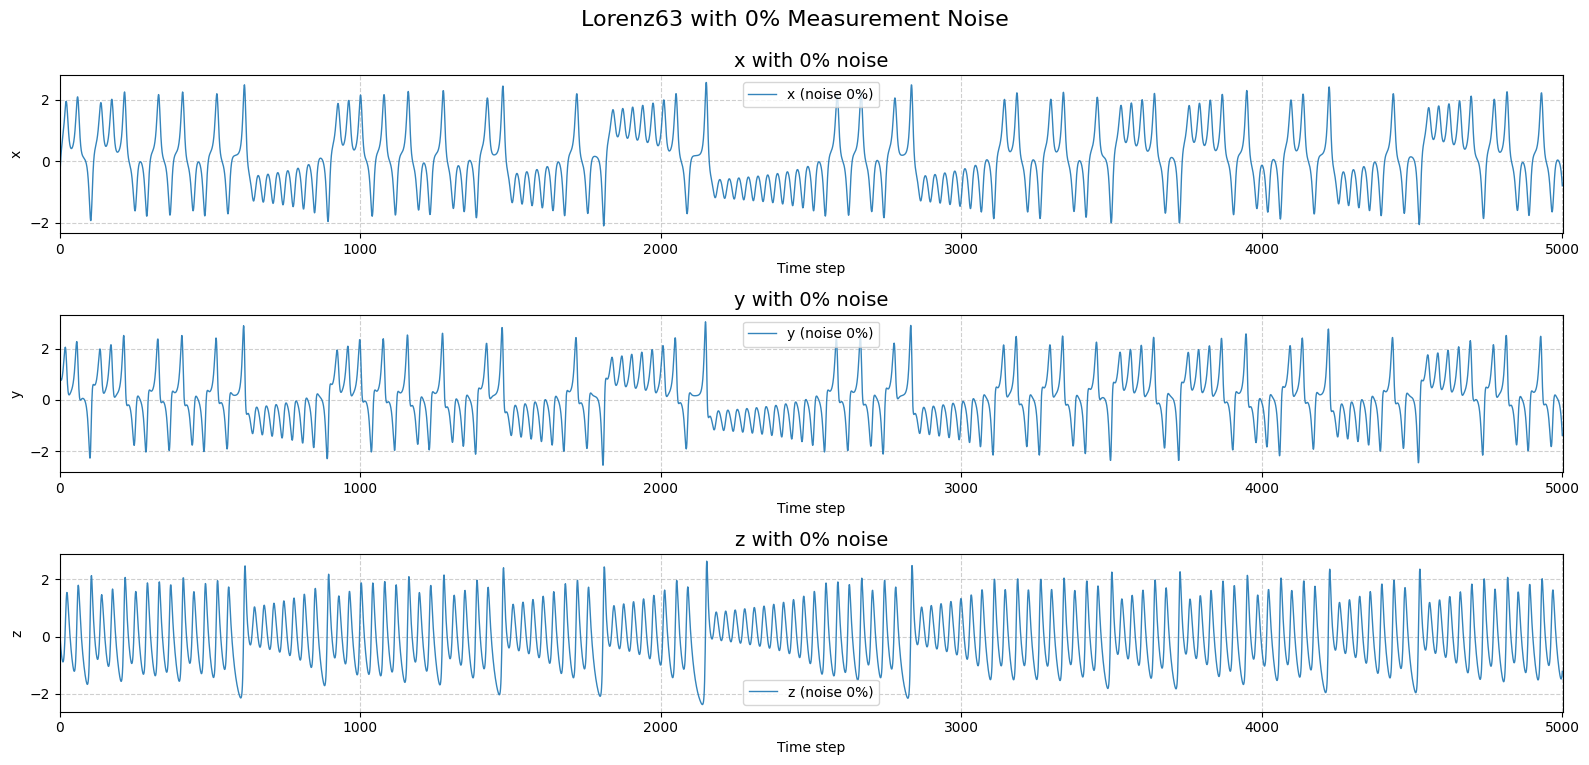

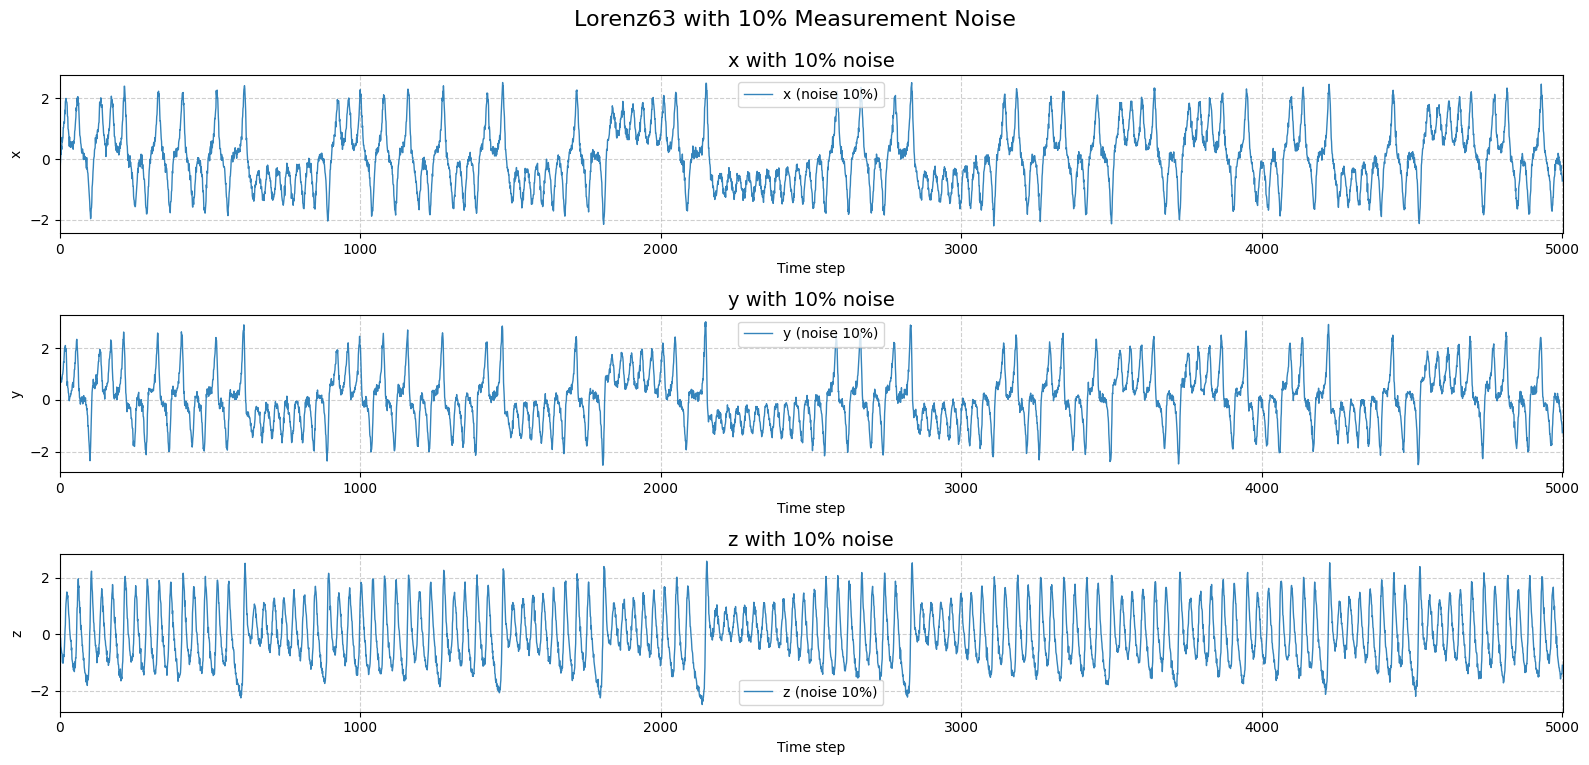

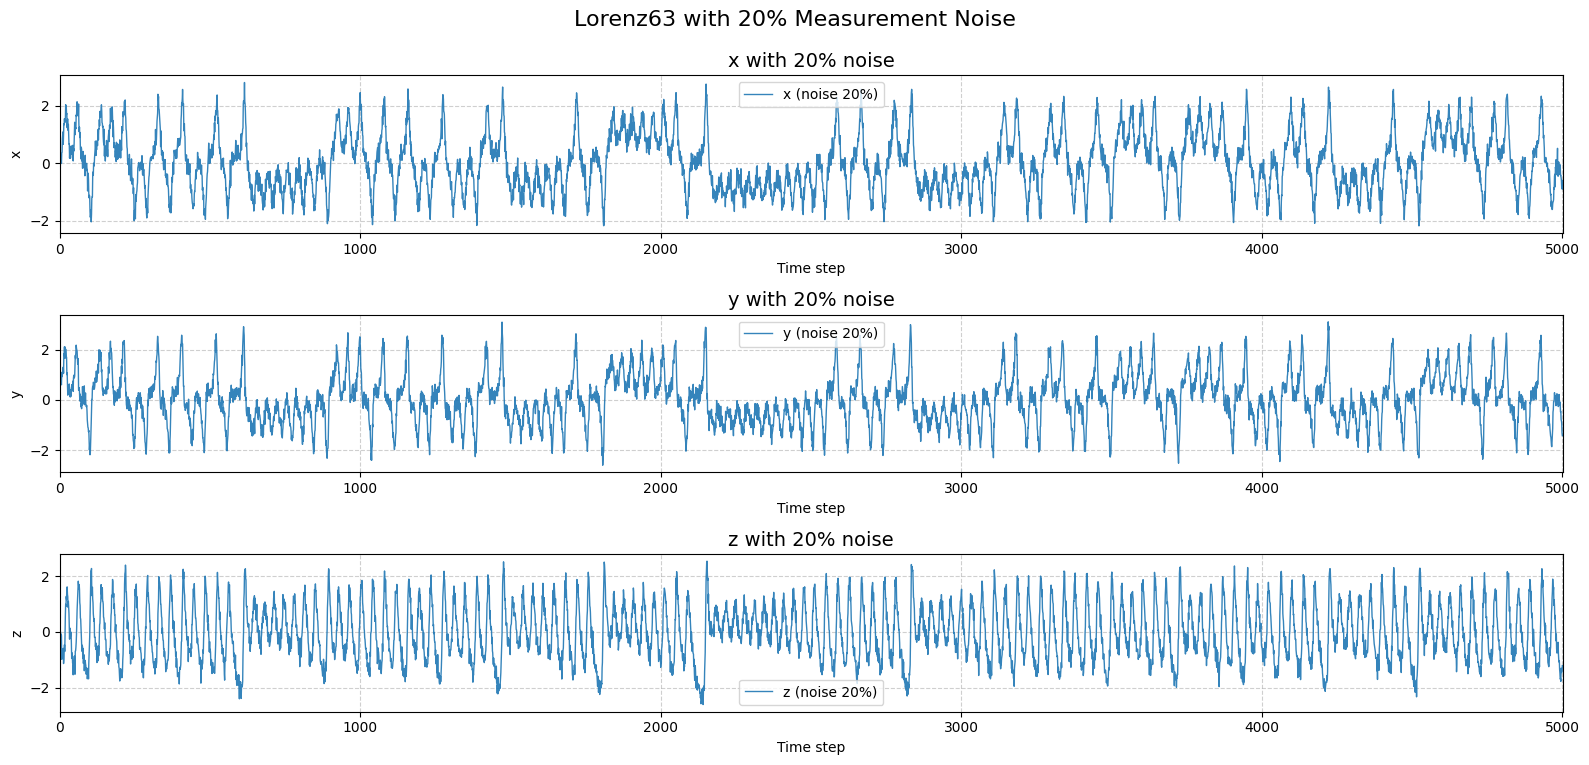

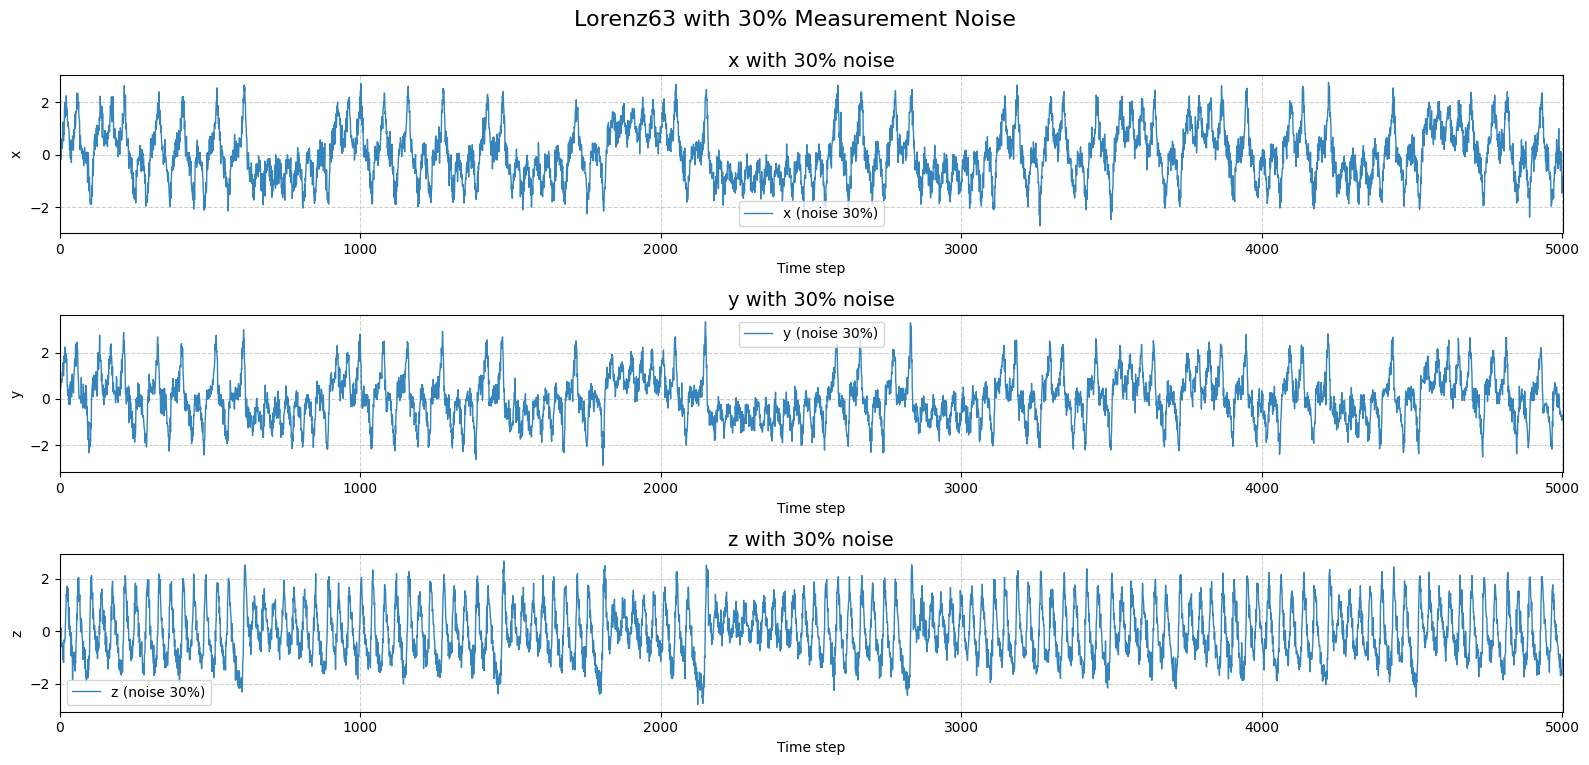

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Load datasets with different noise levels
# -----------------------------------------------------------
noise_levels = [0, 10, 20, 30]
datasets = {}

for nl in noise_levels:
    data = np.load(f"lorenz63_noise_{nl}.npy", allow_pickle=True).item()
    datasets[nl] = data["data"].T  # shape (T, 3)

# -----------------------------------------------------------
# Plot: one figure per noise level
# -----------------------------------------------------------
variables = ["x", "y", "z"]
timesteps = np.arange(datasets[0].shape[0])

for nl in noise_levels:
    plt.figure(figsize=(16, 8))
    for i in range(3):  # loop over variables
        plt.subplot(3, 1, i + 1)
        plt.plot(timesteps, datasets[nl][:, i],
                 label=f"{variables[i]} (noise {nl}%)",
                 linewidth=1.0, alpha=0.9)
        plt.title(f"{variables[i]} with {nl}% noise", fontsize=14)
        plt.xlabel("Time step")
        plt.ylabel(variables[i])
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend()
        plt.xlim(0, 5001)
    plt.suptitle(f"Lorenz63 with {nl}% Measurement Noise", fontsize=16, y=0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    plt.show()


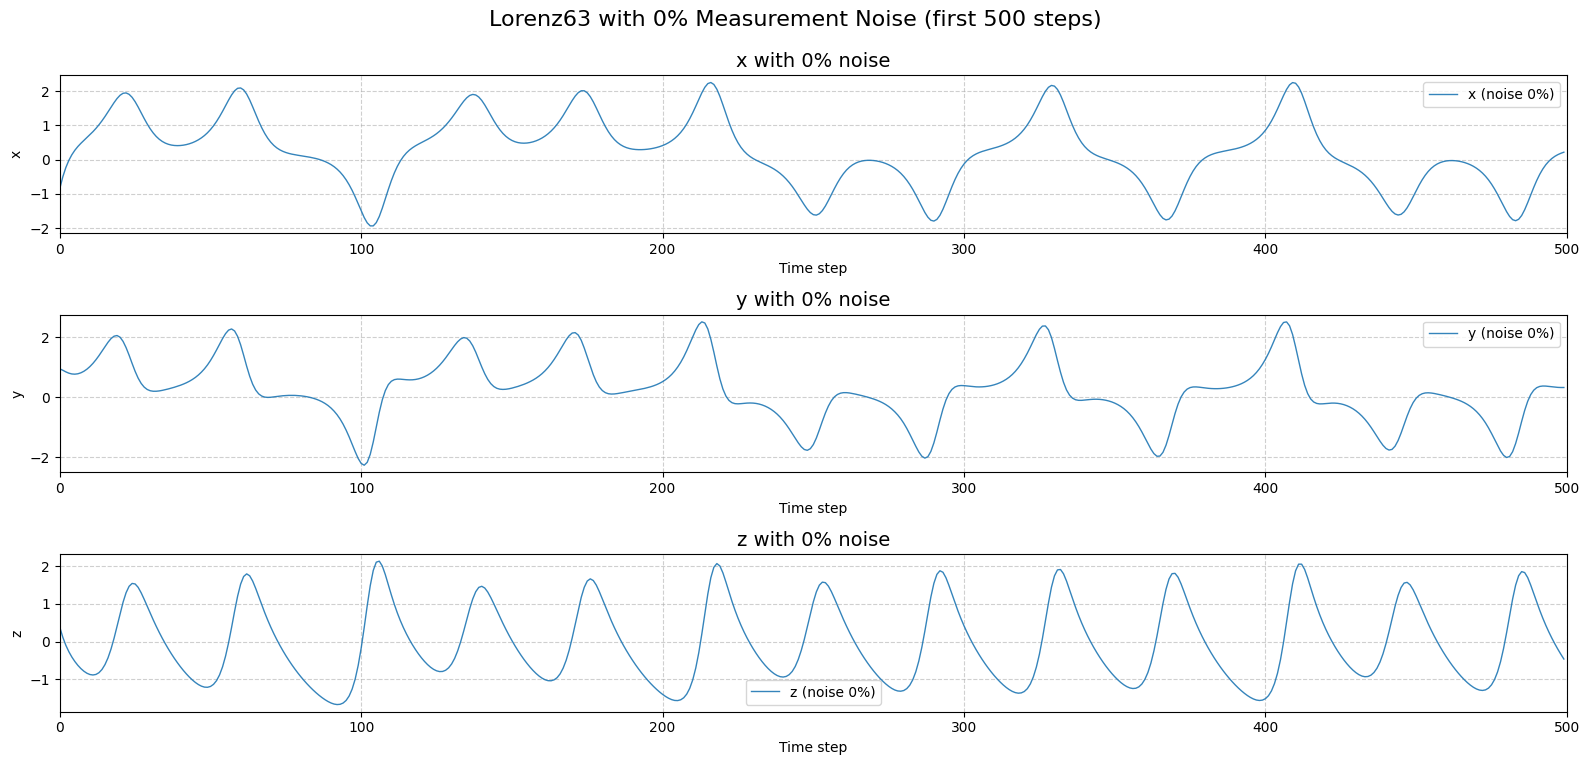

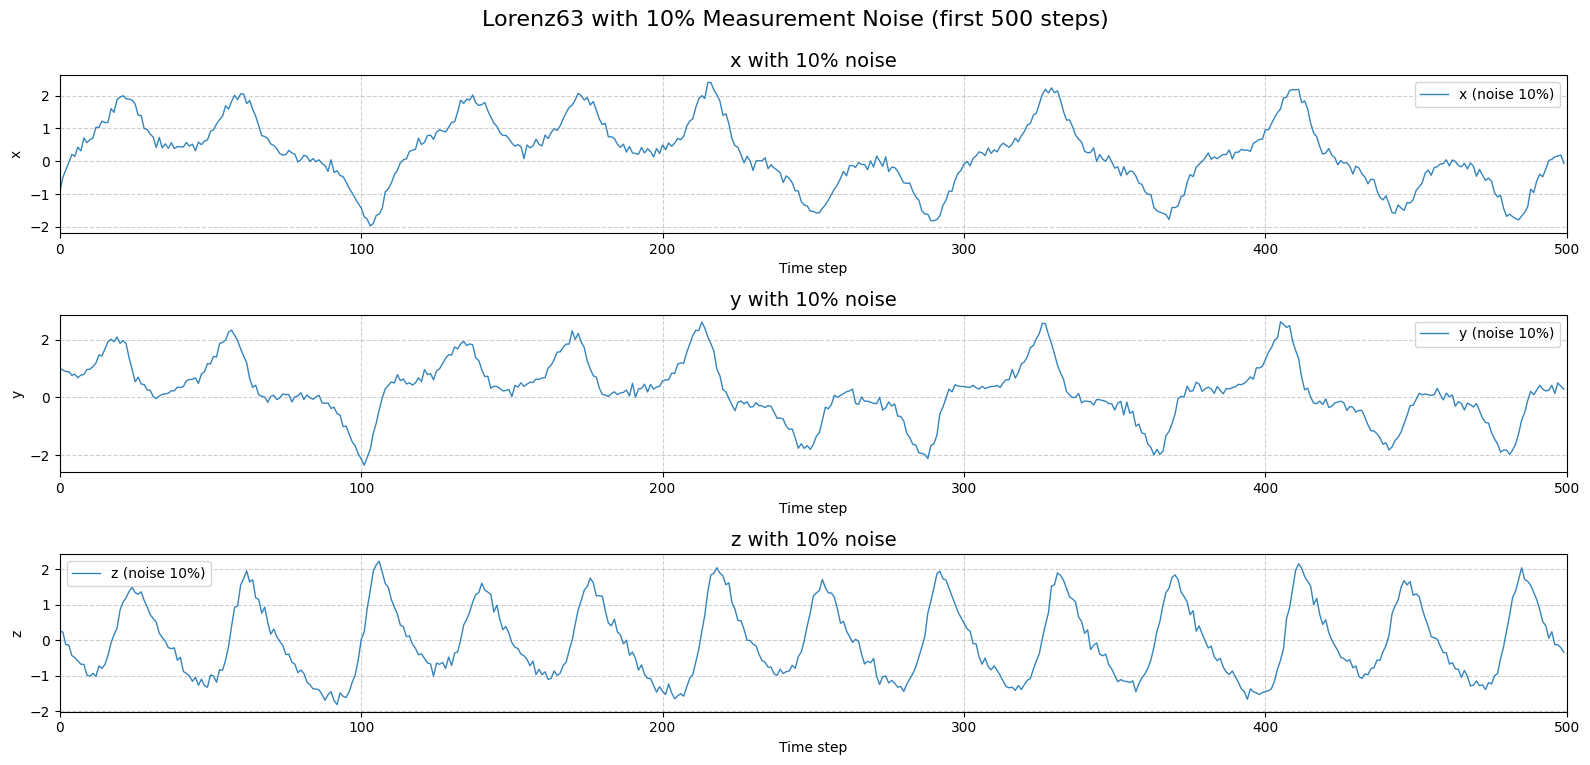

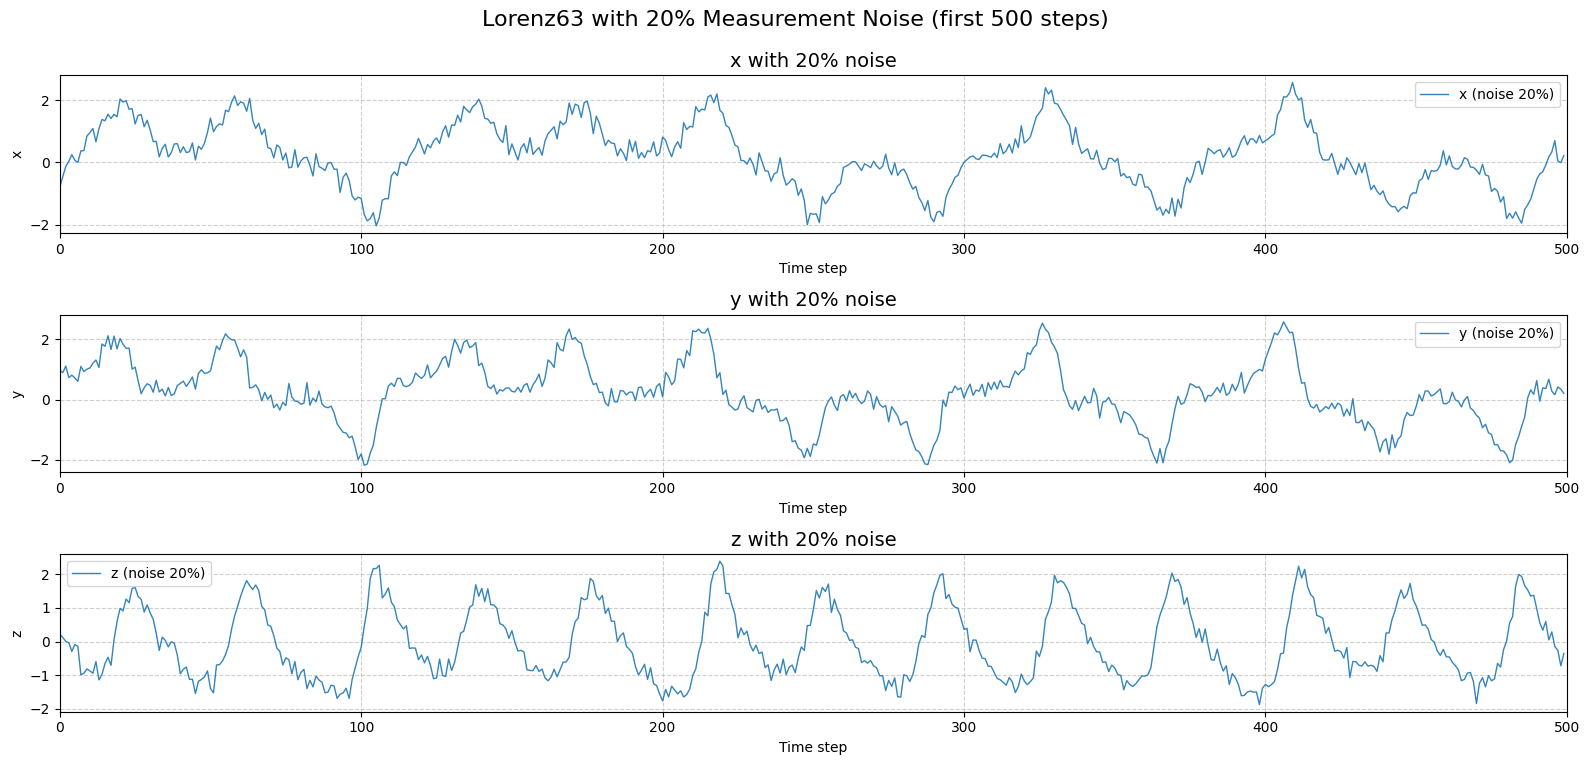

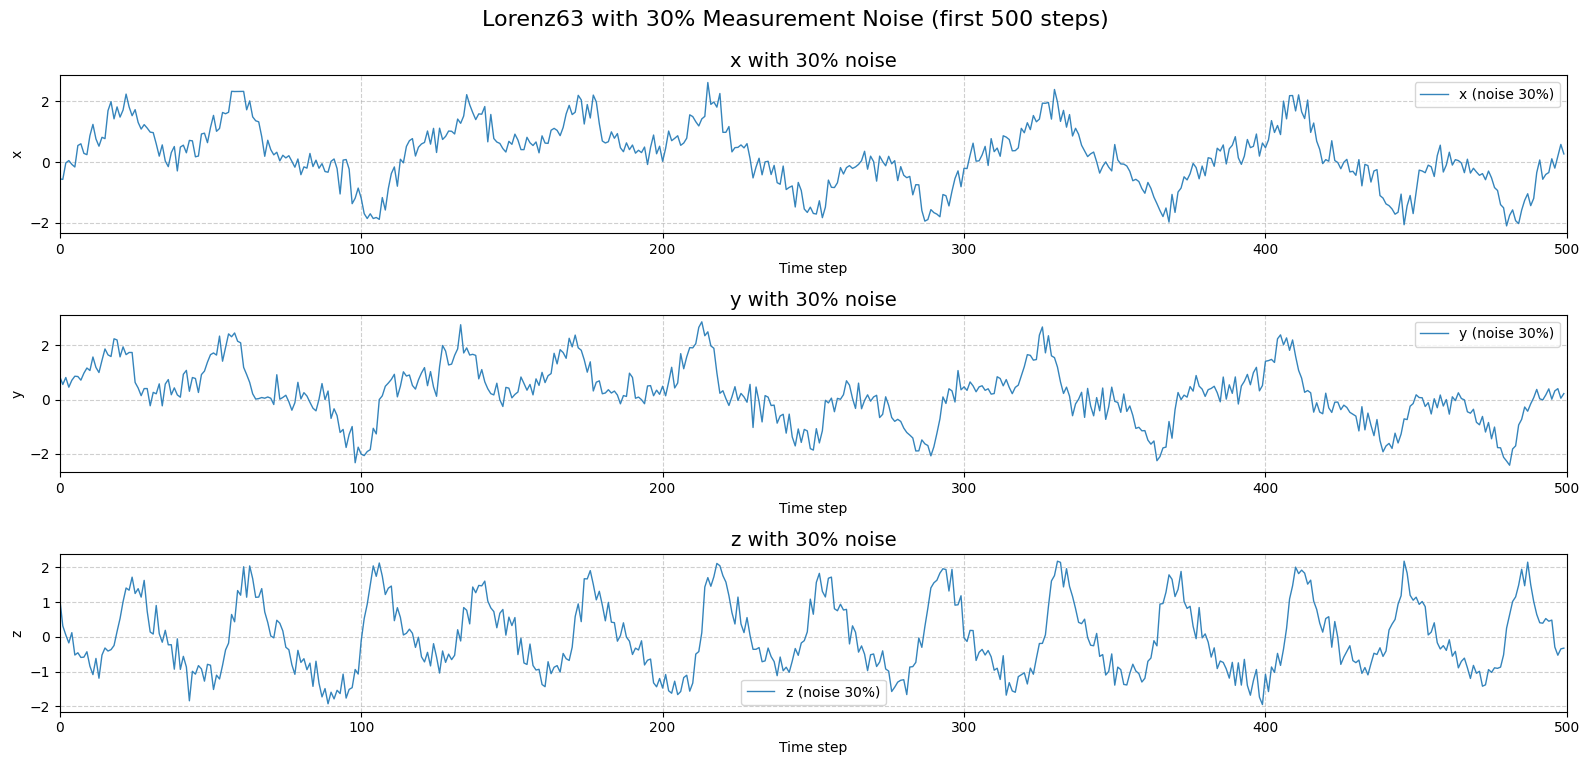

In [3]:
# -----------------------------------------------------------
# Plot: one figure per noise level (first 500 steps)
# -----------------------------------------------------------
variables = ["x", "y", "z"]
timesteps = np.arange(datasets[0].shape[0])

for nl in noise_levels:
    plt.figure(figsize=(16, 8))
    for i in range(3):  # loop over variables
        plt.subplot(3, 1, i + 1)
        plt.plot(timesteps[:500], datasets[nl][:500, i],
                 label=f"{variables[i]} (noise {nl}%)",
                 linewidth=1.0, alpha=0.9)
        plt.title(f"{variables[i]} with {nl}% noise", fontsize=14)
        plt.xlabel("Time step")
        plt.ylabel(variables[i])
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend()
        plt.xlim(0,500)
    plt.suptitle(f"Lorenz63 with {nl}% Measurement Noise (first 500 steps)", fontsize=16, y=0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()